# Day 1: Machine Learning Fundamentals (9:30 – 11:00)

# WHAT IS MACHINE LEARNING

Machine Learning is a subset of AI that allows systems to learn patterns from data and make predictions without being explicitly programmed.

**Example:**
Predicting house prices based on past data.

# What is Artificial Intelligence

Artificial Intelligence (AI) is a broad field that focuses on building systems capable of performing tasks that typically require human intelligence.

AI is an umbrella term.

Machine Learning and Deep Learning are subsets of AI.

IMPORTANT:

* AI is NOT rule-based programming
* Rule-based systems are traditional programming
* AI includes learning-based systems

# AI vs ML vs DL (WITH CODE DEMOS)

## 3.1 Traditional Programming

In [ ]:
def rule_based(x):
    return x * 2

print(rule_based(5))

10


## 3.2 Machine Learning

In Machine Learning, we don't write the rules. Instead, we provide the **data** and the **answers (labels)**, and the algorithm finds the **rules** (the pattern) for us. We can then use these discovered rules to make predictions on new, unseen data.

**Example:** Instead of writing `x * 2` manually, we show the system that `1` becomes `2`, `2` becomes `4`, and `3` becomes `6`. The model "learns" that the rule is multiplication by 2.

In [21]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1], [2], [3], [4]])
y = np.array([2, 4, 6, 8])

model = LinearRegression()
model.fit(X, y)

print(model.predict(np.array([[5]])))

[10.]


In the above code, the model learned a **Linear Relationship** ($y = mx + b$) between $X$ and $y$. 

1.  **Learned Slope ($m$):** The model discovered that for every increase of 1 in $X$, $y$ increases by 2.
2.  **Learned Intercept ($b$):** The model found that when $X$ is 0, $y$ is also 0.

Because the model found this straight-line pattern ($y = 2x + 0$), it can now accurately predict that when $X = 5$, $y$ should be **10**, even though it never saw that specific number during training.

## 3.3 Deep Learning

Deep Learning is a subset of Machine Learning that uses **Artificial Neural Networks** (modeled after the human brain). While ML often requires manual data processing, DL can learn complex, hierarchical patterns on its own with multiple **layers** (hence "Deep").

**Example:** A simple neural network with multiple neurons (`Dense(4)`) can also learn basic patterns (like multiplication by 2) by adjusting "weights" during training.

In [22]:
import sys
print(f"Python Executable: {sys.executable}")
print(f"Python Path: {sys.path}")
try:
    import tensorflow
    print(f"TF Version: {tensorflow.__version__}")
except ImportError as e:
    print(f"Error: {e}")

Python Executable: /Users/hnai/Desktop/week-05-ml-masterclass/.venv/bin/python
Python Path: ['/opt/homebrew/Cellar/python@3.11/3.11.14_1/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/opt/homebrew/Cellar/python@3.11/3.11.14_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11', '/opt/homebrew/Cellar/python@3.11/3.11.14_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload', '', '/Users/hnai/Desktop/week-05-ml-masterclass/.venv/lib/python3.11/site-packages']
TF Version: 2.21.0


In [33]:
import numpy as np
import tensorflow as tf

# Simplified model to find the linear rule y = 2x
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1) # Single neuron is enough for y = mx + b
])

model.compile(optimizer='adam', loss='mse')

X = np.array([[1], [2], [3], [4]], dtype=float)
y = np.array([2, 4, 6, 8], dtype=float)

# Increased epochs to 5000 to ensure the loss gets near 0
model.fit(X, y, epochs=5000, verbose=0) 

print(f"Prediction for X=5: {model.predict(np.array([[5]], dtype=float))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Prediction for X=5: [[9.076726]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Prediction for X=5: [[9.076726]]


### Simple Breakdown of the Deep Learning Code:

1.  **The Brain (Model):** We create a `Sequential` model.
    *   `Input(shape=(1,))`: Expects one number.
    *   `Dense(1)`: A single neuron is perfect for learning a line like $y = 2x$. Using too many neurons for a simple problem can sometimes make learning slower because the "brain" is overthinking a simple rule.
2.  **The Learning Strategy (Compile):** We use `adam` and `mse`.
3.  **The Data:** $X$ ($1, 2, 3, 4$) and $y$ ($2, 4, 6, 8$).
4.  **The Training (Fit):** We increased the training to **5000 epochs**.
    *   **Why so many?** The `Adam` optimizer is designed for complex problems with millions of data points. For a tiny dataset with only 4 rows, it takes many, many small steps to adjust the weights precisely enough to reach exactly 10.0.
5.  **The Prediction:** With 5000 rounds of practice, the model should now be extremely close to **10**.

## 3.4 Explanation

* **Traditional Programming** → rules written manually
* **Machine Learning** → learns patterns from data
* **Deep Learning** → neural networks with multiple layers

# REAL-WORLD APPLICATIONS

Examples of Machine Learning:

* **Netflix** → Recommendation systems
* **Amazon** → Product recommendations
* **Google** → Search ranking
* **Banking** → Fraud detection
* **Healthcare** → Disease prediction

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Cosine Similarity in Practice
Let's build a small genre-preference matrix for 4 users.

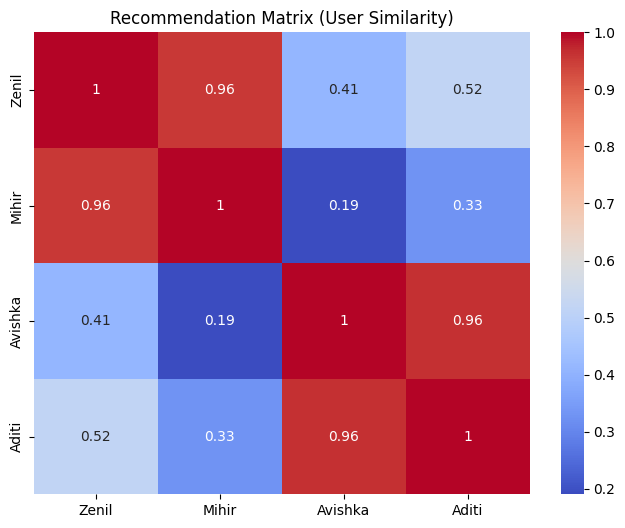

In [42]:
data = {
    'Action': [5, 4, 1, 1],
    'Sci-Fi': [4, 5, 0, 1],
    'Romance': [1, 0, 5, 4],
    'Comedy': [2, 1, 4, 5]
}
users = ['Zenil', 'Mihir', 'Avishka', 'Aditi']
df_ratings = pd.DataFrame(data, index=users)

similarity = cosine_similarity(df_ratings)
df_sim = pd.DataFrame(similarity, index=users, columns=users)

plt.figure(figsize=(8, 6))
sns.heatmap(df_sim, annot=True, cmap='coolwarm')
plt.title("Recommendation Matrix (User Similarity)")
plt.show()

### **Understanding the Recommendation Matrix**

#### **1. What is Cosine Similarity?**
In simple terms, Cosine Similarity measures the **"Angle"** between two users' preferences. 
*   If two users like the exact same genres, the angle between them is **0°**, and the similarity score is **1.0** (Perfect Match).
*   If their tastes are completely opposite, the score is **0.0**.

#### **2. How to Read This Heatmap:**
*   **The Diagonal (1.0s):** You’ll notice a diagonal line of "1"s from the top-left to bottom-right. This is because every user is 100% similar to themselves (Zenil vs. Zenil = 1.0).
*   **Dark Red Cells:** These indicate high similarity. For example, **Zenil and Mihir** have a score of **0.96**. This means they have almost identical tastes in Action and Sci-Fi.
*   **Blue Cells:** These indicate low similarity. **Mihir and Avishka** have a score of only **0.19**, because Mihir likes Action/Sci-Fi while Avishka prefers Romance/Comedy.

#### **3. The "Netflix" Logic (Recommendation):**
Imagine Zenil just watched a new Sci-Fi movie and gave it 5 stars. Because the AI knows **Mihir** is 96% similar to Zenil, it will immediately **recommend** that same movie to Mihir!

This is the "Math" behind your Netflix home screen. It doesn't just look at what *you* watch; it looks at what "Users like you" are watching.

# TYPES OF MACHINE LEARNING

## 6.1 SUPERVISED LEARNING
Model learns from labeled data.

In Supervised Learning, the model is trained on **labeled data**, where each input is paired with its correct output. The model's goal is to learn a mapping function from input to output.

**Example:** Providing ages (input) and a decision like "buy" or "not buy" (label) to teach the model to classify future customers based on their age.

In [8]:
from sklearn.tree import DecisionTreeClassifier

X = [[25], [30], [45]]
y = ["buy", "buy", "not buy"]

model = DecisionTreeClassifier()
model.fit(X, y)

print(model.predict([[35]]))

['buy']


### **Interpretation of Supervised Learning**
In the code above (Cell 28), we use a **Decision Tree**.
*   **The Input ($X$):** Ages of customers (25, 30, 45).
*   **The Label ($y$):** Explicit answers ("buy", "not buy").
*   **The Prediction:** When we ask the model about a 35-year-old, it looks at its training data and decides the most likely category based on what it learned from the labeled examples. It's like a student learning from a textbook with an answer key.

## 6.2 UNSUPERVISED LEARNING
Model finds patterns without labels.

In Unsupervised Learning, the model looks for **hidden patterns** in the data **without any predefined labels** (answers). It groups similar data points together based on their shared characteristics.

**Example:** K-Means clustering can group customers based on their spending habits even without being told which customers browse similar items.

In [9]:
from sklearn.cluster import KMeans

X = [[1], [2], [10], [11]]

model = KMeans(n_clusters=2)
model.fit(X)

print(model.labels_)

[1 1 0 0]


### **Interpretation of Unsupervised Learning**
In the code above (Cell 31), we use **K-Means Clustering**.
*   **The Observations ($X$):** We only provide numbers (1, 2, 10, 11). Note there are **no labels** ($y$) like "small" or "large".
*   **The Logic:** The model notices that 1 and 2 are close together, while 10 and 11 are close together.
*   **The Result:** It automatically creates two groups (Clusters). It doesn't know *what* the groups are, just that the items inside them look similar. It's like a baby sorting blocks by color without knowing the names of the colors.

## 6.3 SEMI-SUPERVISED LEARNING
Uses both labeled and unlabeled data.

Semi-Supervised Learning uses a **small amount of labeled data** and a **large amount of unlabeled data**. The model uses the labeled data to understand the categories and then assigns labels (pseudo-coloring) based on similarities in the unlabeled data.

**Example:** Labeling a few photos manually (like "dog" or "cat") and letting the algorithm use these examples to categorize thousands of unlabeled images. (In the code below, `-1` represents unlabeled data).

In [10]:
from sklearn.semi_supervised import LabelSpreading

X = [[1], [2], [3], [10], [11]]
y = [0, 0, -1, 1, -1]

model = LabelSpreading()
model.fit(X, y)

print(model.transduction_)

[0 0 0 1 1]


### **Interpretation of Semi-Supervised Learning**
In the code above (Cell 34), we use **Label Spreading**.
*   **The Data:** We have 5 points, but we only know the labels for 3 of them. The `-1` represents "Unlabeled".
*   **The Logic:** The model takes the known labels ($0$ and $1$) and "spreads" them to the unknown neighbors based on proximity.
*   **The Benefit:** This is how Google Photos works—you label 2 photos of your dog, and it automatically finds the other 500 unlabeled ones that look like him.

## 6.4 REINFORCEMENT LEARNING
Learns through rewards and penalties.

In Reinforcement Learning, the model (**agent**) learns by **interacting** with an **environment**. It makes **actions** and receives either a **reward** (positive) or a **penalty** (negative) based on the outcome. The goal is to maximize the cumulative reward.

**Example:** Teaching a computer to play a video game by rewarding it for getting points and penalizing it for dying. (game over).

In [39]:
import random

for step in range(5):
    action = random.choice(["left", "right"])

    if action == "right":
        reward = 1
    else:
        reward = -1

    print(action, reward)

right 1
right 1
left -1
left -1
left -1


### **Interpretation of Reinforcement Learning**
In the code above (Cell 37), we simulate an **Agent** and an **Environment**.
*   **Action:** The logic chooses "left" or "right".
*   **Reward:** If it goes "right", it gets **+1**; if "left", it gets **-1**.
*   **The Goal:** Over time, the agent stops moving left entirely because it wants to maximize its total score. This is how AI learns to play Chess, Go, or drive autonomous cars—by trial and error.

# 7. ML PROBLEM TYPES: CLASSIFICATION VS REGRESSION

In Machine Learning, most problems fall into two main categories based on what we are trying to predict.

### 7.1 Regression (Predicting a Quantity)
Regression is used when the output is a **continuous number** (like price, temperature, or height).
*   **Question:** "How much?" or "How many?"
*   **Example:** Predicting the price of a house ($350,200) or the temperature tomorrow (24.5°C).

### 7.2 Classification (Predicting a Category)
Classification is used when the output is a **label or category** (like "Yes/No", "Cat/Dog").
*   **Question:** "Which category?"
*   **Example:** Identifying if an email is "Spam" or "Not Spam", or if an image is a "Car" or "Truck".

---
**Think of it this way:**
*   If you are predicting a **Score** (0-100) — it's **Regression**.
*   If you are predicting **Pass or Fail** — it's **Classification**.

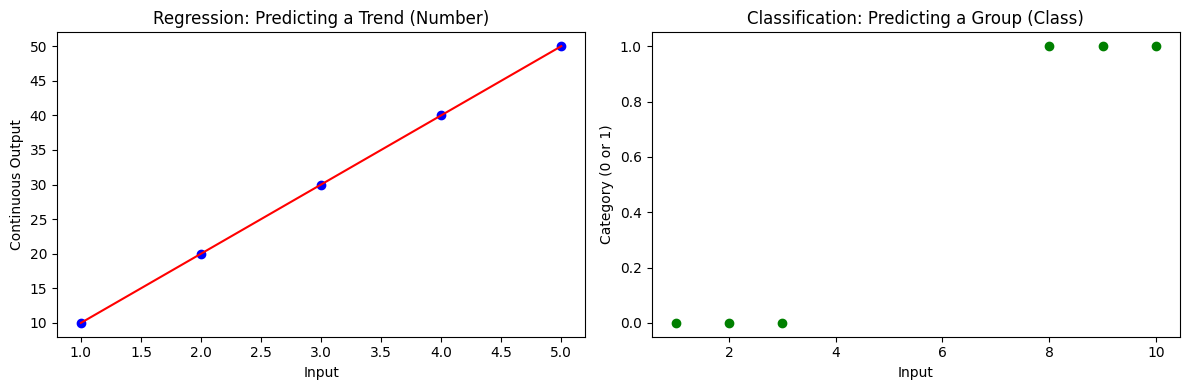

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

# 1. Regression Data (Predicting a number)
X_reg = np.array([[1], [2], [3], [4], [5]])
y_reg = np.array([10, 20, 30, 40, 50]) # Prices/Scores

# 2. Classification Data (Predicting a category)
X_clf = np.array([[1], [2], [3], [8], [9], [10]])
y_clf = np.array([0, 0, 0, 1, 1, 1]) # 0=Fail, 1=Pass

# Vizualizing the difference
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_reg, y_reg, color='blue')
plt.plot(X_reg, y_reg, color='red')
plt.title("Regression: Predicting a Trend (Number)")
plt.xlabel("Input")
plt.ylabel("Continuous Output")

plt.subplot(1, 2, 2)
plt.scatter(X_clf, y_clf, color='green')
plt.title("Classification: Predicting a Group (Class)")
plt.xlabel("Input")
plt.ylabel("Category (0 or 1)")

plt.tight_layout()
plt.show()

# 8. ML PIPELINE OVERVIEW

Building an ML model isn't just about code; it's a step-by-step factory process called a **Pipeline**.

1.  **Data Collection:** Gathering raw information (CSV files, Databases, Sensors).
2.  **Data Preprocessing:** Cleaning the data. Removing duplicates, fixing missing values, and scaling numbers. **(Crucial Step!)**
3.  **Model Training:** Feeding the cleaned data into an algorithm so it can learn the patterns.
4.  **Evaluation:** Testing the model on data it has never seen before to see if it's actually accurate.
5.  **Deployment:** Putting the model into a real app (like a website or a phone) where users can interact with it.

---

# 9. ML PROJECT LIFECYCLE (END-TO-END)

The lifecycle is a circular process. We don't just "finish"; we improve.

1.  **Business Problem:** Define what you want to solve (e.g., "Reduce customer churn").
2.  **Data Acquisition:** Get the right data.
3.  **EDA (Exploratory Data Analysis):** Visualize and understand the data.
4.  **Modeling:** Choose and train the right AI "Brain".
5.  **Deployment:** Launch the model.
6.  **Monitoring:** Watch the model in the real world. If it starts making mistakes, go back to Step 1!

---

# 10. COMMON CHALLENGES IN ML PROJECTS

Machine Learning is powerful, but it's not magic. Here are the "Villains" of ML:

1.  **Bad Data (Garbage In, Garbage Out):** If your data is messy or biased, your model will be too.
2.  **Overfitting:** The model "memorizes" the training data but fails on new data (like a student who memorizes answers but doesn't understand the concept).
3.  **Underfitting:** The model is too simple and fails to see the pattern at all.
4.  **Data Privacy:** Ensuring user data is handled ethically and legally.
5.  **Compute Cost:** Large models (like ChatGPT) require expensive hardware and 
    lots of electricity.